# Dynamic orchestrator — a full run, agent catalog and all

This notebook walks through **`scripts/run_dynamic_orchestrator.py`**'s
actual pipeline cell by cell, using the same functions the CLI script
calls — nothing here is reimplemented. It's the companion to
`end_to_end_pipeline.ipynb` (which walks through the *static*
`run_orchestrator.py`), and the contrast is the point.

The static notebook runs a fixed sequence: intake, then feature
engineering, then profiler, and so on, every time. This notebook runs
a **planning agent** that decides which catalog agent to run next,
given the goal and the current run state — validated deterministically
before anything executes, the same "agents propose, harness decides"
discipline every other agent in this project follows, applied to
control flow instead of just content.

Two things this notebook demonstrates end to end:
1. A full classification run (Titanic) — the planner sequences through
   the same effective stages the static pipeline hardcodes, but by
   deciding each one, not by following a script.
2. A **different goal routing to a different agent sequence** — the
   concrete proof this is doing something a fixed pipeline structurally
   cannot express. See PROJECT_OVERVIEW.md §8.5 for the full design
   rationale, and `runs/dynamic_eval_report.md` for a real-LLM
   evaluation report (parity, task-routing, and an adversarial
   prompt-injection scenario) beyond what one notebook run shows.

## 0. Setup — locate the repo, load `.env`, import everything

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display, Markdown


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "agentic_ml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (expected to find src/agentic_ml/ above cwd)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "src"))
os.chdir(REPO_ROOT)  # so relative paths (datasets/raw/..., runs/, artifacts/...) match the CLI scripts
print(f"Repo root: {REPO_ROOT}")

Repo root: /home/ubuntupc/Documents/Github/agentic-ai-project/agentic-ml-classification


In [2]:
def load_env_file(path: Path) -> None:
    if not path.exists():
        print(f"No .env file found at {path} — assuming environment variables are already set.")
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip().strip('"').strip("'"))


load_env_file(REPO_ROOT / ".env")
assert (
    os.environ.get("RIT_API_KEY")
    or os.environ.get("MODEL_GATEWAY_BASE_URL")
    or os.environ.get("LOCAL_MODEL_BASE_URL")
), (
    "No RIT_API_KEY, MODEL_GATEWAY_BASE_URL, or LOCAL_MODEL_BASE_URL found. "
    "Copy .env.example to .env and fill in credentials for at least one endpoint "
    "before running this notebook."
)
print("Environment loaded (secrets not printed).")

Environment loaded (secrets not printed).


In [3]:
import joblib
from sklearn.metrics import auc, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

from agentic_ml.cli_common import make_run_dir, make_tracer, make_transcript_writer, resolve_model_endpoint
from agentic_ml.harness.attribution import compute_background
from agentic_ml.harness.dataset import read_dataframe
from agentic_ml.mcp_facts.provider import McpToolProvider
from agentic_ml.mcp_facts.transport import HttpMcpTransport, McpToolError
from agentic_ml.model_client import ModelClient
from agentic_ml.orchestrator.agent_registry import list_agent_summaries
from agentic_ml.orchestrator.dynamic_loop import load_raw_hash, run_dynamic_loop
from agentic_ml.orchestrator.run_state import DynamicRunContext, RunStateSummary
from agentic_ml.templates.sources.xgboost_mixed import build_pipeline

print("Imports OK.")

Imports OK.


## 1. The agent catalog

`orchestrator/agent_registry.py` — the fixed, auditable menu the
planner picks from. Each entry declares `required_state`: the
preconditions that must hold in the *real* run state before the
harness will let the planner's proposal execute (checked in
`orchestrator/dynamic_loop.py::validate_plan`, never taken on the
planner's word).

In [4]:
catalog_df = pd.DataFrame(list_agent_summaries(capabilities={"deep_dive"}))
display(catalog_df[["agent_id", "title", "when_to_use", "required_state"]])

,agent_id,title,when_to_use,required_state
0,intake,Intake,"First step, whenever the target column isn't a...",{'target_known': False}
1,feature_engineering,Feature Engineering,"Immediately after the target is known, exactly...","{'target_known': True, 'feature_engineering_do..."
2,profiler,Profiler,After feature engineering has run (even if it ...,"{'target_known': True, 'feature_engineering_do..."
3,split_and_check_leakage,Split + Leakage Checks,"Immediately after the profiler, exactly once.","{'profiler_done': True, 'split_done': False}"
4,modeling,Modeling,After the split passes its leakage checks. Cal...,{'split_leakage_passed': True}
5,verification,Verification,Whenever a gate-passing candidate hasn't been ...,{'has_unverified_passing_candidate': True}
6,finalize,Finalize,Once at least one candidate has been verified ...,"{'has_verified_candidate': True, 'final_test_m..."
7,deep_dive,Deep-Dive,A different question than classification ('why...,{'model_path_available': True}
8,summarize,Summarize,"After finalize, once — the natural last step b...","{'final_test_metrics_present': True, 'summary_..."


## 2. Configuration

Edit this cell for your dataset/endpoint, then run everything below it
in order. Three model endpoints are supported (see README.md "Three
model endpoints"); **`LOCAL` at the top of the next cell is the one
switch you need to flip when handing this notebook to someone without
a local model server running**:

- `LOCAL = True` — a local OpenAI-compatible server (vLLM/Ollama/SGLang)
  on this machine. Needs `LOCAL_MODEL_BASE_URL` in `.env`. Fast and
  reliable for notebook iteration, but not what a teammate without that
  server set up can use.
- `LOCAL = False` — RIT's API directly. This is what anyone without a
  local model server should use. Needs `RIT_API_KEY` and `RIT_BASE_URL`
  in `.env` (copy `.env.example` to `.env` and fill in the API key).

A third option (the LiteLLM gateway, `use_gateway` inside `CONFIG`)
exists for routing multiple callers through one endpoint — see
README.md — but `LOCAL` is the only thing most people need to touch.

There's also a separate, independent toggle for *how agents get their
tool facts* (dataset profile, template catalog, etc.), not which model
answers them: `USE_MCP` in the same cell. Default `False` keeps
today's in-process closures (`tools/*.py`) — nothing else to do.
Setting it `True` routes those facts through the MCP (Model Context
Protocol) fact server instead (see README.md's "MCP fact server"
entry), which must already be running in a separate terminal first:

```bash
python scripts/run_mcp_server.py
```

This notebook fails fast with a clear message if `USE_MCP = True` and
that server isn't reachable, rather than a confusing error deep inside
the first agent step that needs a tool.

In [5]:
# =====================================================================
# ENDPOINT SELECTION — flip this one line when running without a local
# model server (e.g. handing the notebook to a teammate):
#
#   LOCAL = True   -> local OpenAI-compatible server (vLLM/Ollama/SGLang).
#                     Needs LOCAL_MODEL_BASE_URL in .env.
#   LOCAL = False  -> RIT's API directly. Needs RIT_API_KEY and
#                     RIT_BASE_URL in .env (copy .env.example -> .env
#                     and fill in the key). Use this if you don't have
#                     a local model server running.
# =====================================================================
LOCAL = True

# =====================================================================
# TOOL ROUTING (optional, independent of the endpoint above) — flip to
# True to route agent tool facts (dataset profile, template catalog,
# etc.) through the MCP fact server (mcp_facts/server.py) instead of
# in-process closures. The server must already be running:
#   python scripts/run_mcp_server.py
# =====================================================================
USE_MCP = True
MCP_URL = "http://127.0.0.1:8765/mcp"

CONFIG = {
    "data_path": "datasets/raw/C28.csv",
    "goal": "",
    "target_column": None,        # None lets the intake agent infer it — part of the demo
    "group_column": None,
    "time_column": None,
    "id_columns": None,
    "strategy": None,             # None = use the profiler's recommendation
    "seed": 42,
    "metrics": ["roc_auc", "pr_auc", "f1", "accuracy"],
    "max_iterations": 15,         # hard cap on planner turns
    "model": None,                # None = endpoint default
    "verification_model": None,   # None = a reasoning-oriented default, distinct from "model"
    "use_gateway": False,         # advanced: route through the LiteLLM gateway instead — see README.md
    "use_local": LOCAL,
    "use_mcp": USE_MCP,           # route agent tool facts through the MCP server instead of in-process
    "mcp_url": MCP_URL,
    "run_id": None,               # None = auto-generate
}

# Fail fast with a clear message instead of a confusing error deep inside
# ModelClient if the .env value the chosen endpoint needs isn't set.
if CONFIG["use_local"]:
    assert os.environ.get("LOCAL_MODEL_BASE_URL"), (
        "LOCAL = True but LOCAL_MODEL_BASE_URL is not set in .env. Either start a "
        "local OpenAI-compatible server and set it, or set LOCAL = False above "
        "to use RIT's API instead."
    )
elif CONFIG["use_gateway"]:
    assert os.environ.get("MODEL_GATEWAY_BASE_URL"), (
        "use_gateway = True but MODEL_GATEWAY_BASE_URL is not set in .env."
    )
else:
    assert os.environ.get("RIT_API_KEY") and os.environ.get("RIT_BASE_URL"), (
        "LOCAL = False (RIT direct) but RIT_API_KEY/RIT_BASE_URL are not set in "
        ".env. Copy .env.example to .env and fill in your RIT API key."
    )

CONFIG

{'data_path': 'datasets/raw/C28.csv',
 'goal': '',
 'target_column': None,
 'group_column': None,
 'time_column': None,
 'id_columns': None,
 'strategy': None,
 'seed': 42,
 'metrics': ['roc_auc', 'pr_auc', 'f1', 'accuracy'],
 'max_iterations': 15,
 'model': None,
 'verification_model': None,
 'use_gateway': False,
 'use_local': True,
 'use_mcp': True,
 'mcp_url': 'http://127.0.0.1:8765/mcp',
 'run_id': None}

## 3. Model client + run directory

In [6]:
base_url, api_key, default_model = resolve_model_endpoint(
    CONFIG["use_gateway"], CONFIG["model"], "qwen3-coder:30b", "rit-qwen3-coder-30b",
    use_local=CONFIG["use_local"],
)
client = ModelClient(base_url=base_url, api_key=api_key, default_model=default_model)
_, _, verification_model = resolve_model_endpoint(
    CONFIG["use_gateway"], CONFIG["verification_model"], "gemma4:latest", "rit-gemma4-latest",
    use_local=CONFIG["use_local"],
)

run_id, run_dir = make_run_dir(CONFIG["run_id"])
trace = make_tracer(run_dir / "trace.jsonl")
write_transcript = make_transcript_writer(run_dir)


def make_tool_provider(for_run_id: str):
    """None -> steps/*.py fall back to LocalToolProvider (today's
    in-process closures), the default. An McpToolProvider is bound to
    ONE run_id (facts persist under runs/<run_id>/facts/), so this is
    a function, not a single shared object — the bonus routing demo in
    section 9 uses a different run_id than the main run and needs its
    own provider."""
    if not CONFIG["use_mcp"]:
        return None
    return McpToolProvider(for_run_id, HttpMcpTransport(CONFIG["mcp_url"]))


tool_provider = make_tool_provider(run_id)
if CONFIG["use_mcp"]:
    try:
        tool_provider.make_list_templates_tool().handler()  # cheap reachability probe
    except McpToolError as e:
        raise RuntimeError(
            f"USE_MCP = True but the MCP server at {CONFIG['mcp_url']} is not reachable "
            f"({e}). Start it first, in a separate terminal: python scripts/run_mcp_server.py"
        ) from e
    print(f"Tool routing: MCP fact server at {CONFIG['mcp_url']}")
else:
    print("Tool routing: in-process (default)")

endpoint_mode = "LOCAL server" if CONFIG["use_local"] else ("LiteLLM gateway" if CONFIG["use_gateway"] else "RIT direct")
print(f"Endpoint: {endpoint_mode}  (base_url={base_url})")
print(f"run_id: {run_id}")
print(f"run_dir: {run_dir}")
print(f"model: {default_model}   verification_model: {verification_model}")

Tool routing: MCP fact server at http://127.0.0.1:8765/mcp
Endpoint: LOCAL server  (base_url=http://localhost:8000/v1)
run_id: run_b537acdb
run_dir: runs/run_b537acdb
model: Qwen/Qwen3-Coder-30B-A3B-Instruct   verification_model: Qwen/Qwen3-Coder-30B-A3B-Instruct


## 4. Build the initial run context + state

Two objects, deliberately separate: `DynamicRunContext` is the
harness-side working state (dataframes, fitted pipelines) — never
shown to the LLM. `RunStateSummary` is the small, JSON-safe summary the
planner's tool actually returns each turn — the *only* view of run
progress it ever gets.

In [7]:
id_columns = [c.strip() for c in (CONFIG["id_columns"] or "").split(",") if c.strip()]

ctx = DynamicRunContext(
    data_path=CONFIG["data_path"], goal=CONFIG["goal"], seed=CONFIG["seed"],
    target_column=CONFIG["target_column"], group_column=CONFIG["group_column"],
    time_column=CONFIG["time_column"], id_columns=id_columns,
    strategy_override=CONFIG["strategy"], metric_names=CONFIG["metrics"],
    run_id=run_id,
)
ctx.raw_df = read_dataframe(CONFIG["data_path"])

state = RunStateSummary(goal=CONFIG["goal"])
if CONFIG["target_column"]:
    state.target_known = True
    state.target_column = CONFIG["target_column"]
    load_raw_hash(ctx)

print(f"Loaded {len(ctx.raw_df)} rows, {len(ctx.raw_df.columns)} columns from {CONFIG['data_path']}")
display(ctx.raw_df.head())

Loaded 28783265 rows, 28 columns from datasets/raw/C28.csv


,volt1,volt2,amp1,amp2,FQtyL,FQtyR,E1 FFlow,E1 OilT,E1 OilP,E1 RPM,...,OAT,IAS,VSpd,NormAc,AltMSL,id,plane_id,split,date_diff,before_after
0,28.1,28.1,6.4,0.4,20.22,23.84,2.54,74.25,67.50,1229.0,...,-2.2,0.0,13.21,-0.03,838.0,0,37,0,1,0
1,28.1,28.1,6.4,0.4,20.22,23.84,2.54,74.25,67.50,1229.0,...,-2.2,0.0,13.21,-0.03,838.0,0,37,0,1,0
2,28.1,28.1,6.4,0.5,20.27,23.84,2.47,74.25,67.44,1226.0,...,-2.2,0.0,11.15,-0.03,839.0,0,37,0,1,0
3,28.1,28.1,6.3,0.4,20.22,23.89,2.40,74.25,67.44,1228.0,...,-2.2,0.0,0.65,0.02,NaN,0,37,0,1,0
4,28.1,28.1,6.2,0.4,20.22,23.84,2.38,74.25,67.50,1230.0,...,-2.5,0.0,-22.52,-0.02,841.0,0,37,0,1,0


## 5. Run the dynamic loop

This one call *is* the orchestrator: propose -> validate -> execute ->
update state, repeated until the planner proposes `"finish"` or
`max_iterations` is hit. Everything after this cell is just inspecting
what happened — no additional pipeline logic runs below.

In [8]:
result = run_dynamic_loop(
    ctx, state, client, model=default_model, verification_model=verification_model,
    max_iterations=CONFIG["max_iterations"],
    trace_fn=lambda r: trace(**r), write_transcript=write_transcript,
    tool_provider=tool_provider,
)
print(f"Status: {result.status}")
print(f"Iterations used: {len(result.history)}")

KeyboardInterrupt: 

## 6. Walk through what the planner actually decided

Every iteration's proposal, reasoning, and outcome — including any
proposals the deterministic validator rejected before they ever
executed (`orchestrator/dynamic_loop.py::validate_plan`).

In [9]:
for h in result.history:
    n_rejected = len(h.get("attempts", []))
    rejected_note = f"  _(rejected {n_rejected} earlier proposal(s) this iteration first)_" if n_rejected else ""

    if h.get("finished"):
        reasoning = h["proposal"].get("reasoning", "")
        display(Markdown(f"**Iteration {h['iteration']} — FINISH**{rejected_note}\n\n> {reasoning}"))
    elif not h.get("executed"):
        display(Markdown(f"**Iteration {h['iteration']} — planner could not produce a valid proposal**"))
    else:
        outcome = "OK" if h["ok"] else f"FAILED ({'; '.join(h['errors'])})"
        reasoning = h["proposal"].get("reasoning", "")
        display(Markdown(
            f"**Iteration {h['iteration']} — ran `{h['agent_id']}`** -> {outcome}{rejected_note}\n\n> {reasoning}"
        ))

history_df = pd.DataFrame([
    {
        "iteration": h["iteration"],
        "agent_id": h.get("agent_id") or ("finish" if h.get("finished") else None),
        "ok": h.get("ok"),
        "n_rejected_first": len(h.get("attempts", [])),
    }
    for h in result.history
])
display(history_df)

NameError: name 'result' is not defined

## 7. Final results

In [ ]:
if ctx.final_test_metrics:
    metrics_df = pd.DataFrame(ctx.final_test_metrics).T
    display(metrics_df)
    print("\nNOTE: this is the only time the test split is touched (steps/finalize_step.py).")
else:
    print(f"No final_test_metrics — the run ended with status={result.status!r} before reaching finalize.")

,metric,value,ci_low,ci_high,n_bootstrap
roc_auc,roc_auc,0.888929,0.831783,0.94367,200
pr_auc,pr_auc,0.841083,0.748137,0.916269,200
f1,f1,0.745098,0.65262,0.827604,200
accuracy,accuracy,0.804511,0.744173,0.87218,200



NOTE: this is the only time the test split is touched (steps/finalize_step.py).


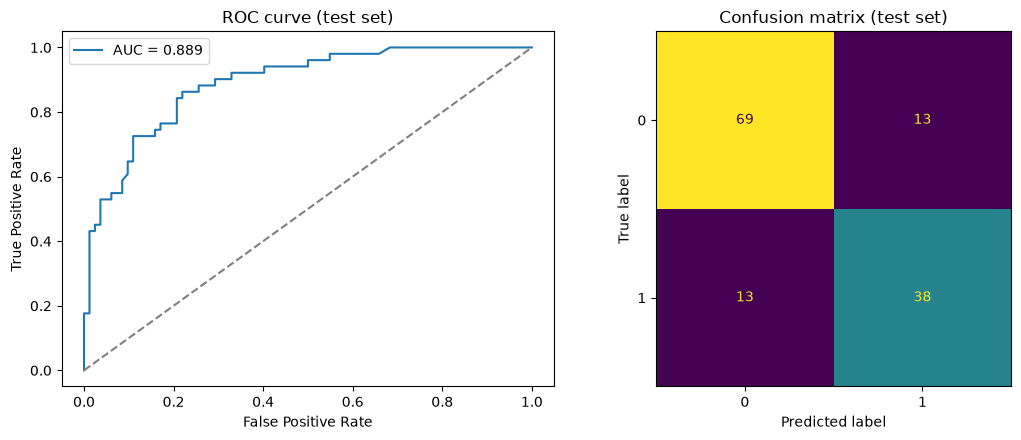

In [ ]:
if ctx.final_pipeline is not None and ctx.manifest is not None:
    y_test = ctx.loaded.y.iloc[ctx.manifest.test_idx]
    y_pred = ctx.final_pipeline.predict(ctx.loaded.X.iloc[ctx.manifest.test_idx])
    proba = ctx.final_pipeline.predict_proba(ctx.loaded.X.iloc[ctx.manifest.test_idx])

    n_classes = y_test.nunique()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_test, proba[:, 1])
        roc_auc_value = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_value:.3f}")
        axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[0].set_xlabel("False Positive Rate")
        axes[0].set_ylabel("True Positive Rate")
        axes[0].set_title("ROC curve (test set)")
        axes[0].legend()
    else:
        axes[0].axis("off")
        axes[0].text(
            0.5, 0.5,
            f"ROC curve not shown for {n_classes}-class targets.\n"
            "See macro one-vs-rest roc_auc in the metrics table above.",
            ha="center", va="center", wrap=True,
        )

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[1], colorbar=False)
    axes[1].set_title("Confusion matrix (test set)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped — no final pipeline available for this run.")

## 8. Narrated summary

Plain-text only — no tools, no decisions, just narration of already-computed facts.

In [ ]:
if ctx.summary_text:
    display(Markdown(f"**Summary:**\n\n{ctx.summary_text}"))
else:
    print("No summary produced (the run didn't reach the summarize step).")

**Summary:**

The model successfully predicted whether passengers survived the Titanic disaster with strong performance across multiple metrics. It achieved an ROC AUC score of 0.889, meaning it's quite good at distinguishing between survivors and victims. The precision-recall AUC score was 0.841, indicating solid performance in identifying actual survivors. The model's accuracy was 0.805, showing it correctly classified about 80% of all passengers. These results suggest the model is reliable for making survival predictions, though there's still room for improvement as it misclassified about 20% of cases. The confidence intervals show these results are statistically significant based on 200 bootstrap samples.

## 9. Bonus: a different goal routes to a different agent sequence

The concrete proof this is doing something a fixed pipeline
structurally cannot: given a goal that only needs the deep-dive agent,
plus a model that's already available, the planner should route
straight there — never touching intake, feature engineering, profiler,
or modeling at all.

For speed and reliability this cell builds a small **synthetic**
aviation-shaped model bundle in-notebook (same shape and code path
`tests/test_dynamic_orchestrator.py`'s routing test uses) rather than
processing the real 4.2GB NGAFID-MC file — for that, see
`scripts/featurize_ngafid_flights.py` + `scripts/run_orchestrator.py`
against `datasets/raw/C28.csv`, or `scripts/evaluate_dynamic_orchestrator.py`'s
real version of this same scenario.

In [ ]:
NGAFID_SENSORS_DEMO = [
    "volt1", "volt2", "amp1", "amp2", "FQtyL", "FQtyR", "E1 FFlow",
    "E1 OilT", "E1 OilP", "E1 RPM", "E1 CHT1", "E1 CHT2", "E1 CHT3",
    "E1 CHT4", "E1 EGT1", "E1 EGT2", "E1 EGT3", "E1 EGT4", "OAT",
    "IAS", "VSpd", "NormAc", "AltMSL",
]

demo_dir = run_dir / "bonus_aviation_demo"
demo_dir.mkdir(parents=True, exist_ok=True)
rng = np.random.RandomState(0)

# one synthetic flight (id=5)'s raw per-timestep trace
raw_rows = {c: rng.normal(100.0, 5.0, 40) for c in NGAFID_SENSORS_DEMO}
raw_rows["AltMSL"] = np.linspace(500, 900, 40)
raw_rows["id"] = 5
raw_csv = demo_dir / "raw_flights.csv"
pd.DataFrame(raw_rows).to_csv(raw_csv, index=False)

# that flight's engineered feature row (what a real featurize_ngafid_flights.py run would produce)
feature_cols = [f"E1 EGT{i}__mean" for i in range(1, 5)] + [f"E1 CHT{i}__mean" for i in range(1, 5)]
features_csv = demo_dir / "features.csv"
pd.DataFrame([{**{c: 1200.0 for c in feature_cols}, "id": 5}]).to_csv(features_csv, index=False)

# a small, real, fitted template pipeline where the label IS a planted cyl-3 fault
train_rows = []
for i in range(60):
    label = i % 2
    row = {c: rng.normal(1200.0, 5.0) for c in feature_cols}
    if label == 1:
        row["E1 EGT3__mean"] += 80.0
    row["label"] = label
    train_rows.append(row)
train_tbl = pd.DataFrame(train_rows)
demo_pipeline = build_pipeline({"numeric_cols": feature_cols, "categorical_cols": [], "seed": 0})
demo_pipeline.fit(train_tbl[feature_cols], train_tbl["label"])
demo_background = compute_background(train_tbl, feature_cols, normal_mask=(train_tbl["label"] == 0))

model_path = demo_dir / "existing_model.joblib"
joblib.dump(
    {"model": demo_pipeline, "feature_columns": feature_cols, "background": demo_background},
    model_path,
)
print(f"Synthetic aviation model bundle written to {model_path}")

Synthetic aviation model bundle written to runs/run_73e86f88/bonus_aviation_demo/existing_model.joblib


In [ ]:
routing_ctx = DynamicRunContext(
    data_path=str(features_csv), goal="explain why flight 5 was flagged for maintenance",
    seed=42, raw_csv=str(raw_csv), features_csv=str(features_csv), run_id=run_id + "_routing",
)
bundle = joblib.load(model_path)
routing_ctx.model_path = str(model_path)
routing_ctx.final_pipeline = bundle["model"]
routing_ctx.model_feature_columns = bundle["feature_columns"]
routing_ctx.model_background = bundle["background"]

routing_state = RunStateSummary(goal=routing_ctx.goal)
routing_state.model_path_available = True  # pre-seeded, like --existing-model on the CLI
# A pre-seeded model means this run isn't doing fresh classification, so
# intake is never relevant — without this, intake looks like a legitimate
# next step (target_known defaults to False) and, for a feature table with
# no plausible target column, fails repeatedly instead of the planner
# going straight to deep_dive. Matches the same fix in
# scripts/run_dynamic_orchestrator.py's --existing-model handling.
routing_state.target_known = True

# Same USE_MCP toggle as the main run above, but its own provider — an
# McpToolProvider is bound to one run_id, and this demo deliberately
# uses a different run_id (run_id + "_routing") than the main run.
routing_tool_provider = make_tool_provider(routing_ctx.run_id)

routing_result = run_dynamic_loop(
    routing_ctx, routing_state, client, model=default_model, verification_model=verification_model,
    max_iterations=5, trace_fn=lambda r: trace(**r), write_transcript=write_transcript,
    tool_provider=routing_tool_provider,
)

executed = [h["agent_id"] for h in routing_result.history if h.get("executed")]
print(f"Status: {routing_result.status}")
print(f"Agents actually run: {executed}")
print("Classification agents (intake/feature_engineering/profiler/split/modeling/verification/finalize)")
print(f"never ran: {not (set(executed) & {'intake', 'feature_engineering', 'profiler', 'split_and_check_leakage', 'modeling', 'verification', 'finalize'})}")

hyp = routing_ctx.deep_dive_results.get("5")
if hyp:
    display(Markdown(f"**Deep-dive hypothesis (flight 5):**\n\n{hyp.hypothesis}"))

## 10. What a static script could not have done here

Section 9's run never touched intake, feature engineering, the
profiler, or modeling — not because they were skipped by a flag, but
because the planner looked at the goal and the available model, and
decided they weren't needed. `run_orchestrator.py` has no equivalent
decision point; it would have run the full classification loop
regardless of what was actually being asked. That's the concrete
difference this notebook set out to show.

## 11. Artifacts written this run

In [ ]:
report = {
    "run_id": run_id, "model": default_model, "status": result.status,
    "final_state": state.to_planner_dict(),
    "history": result.history,
    "final_test_metrics": ctx.final_test_metrics,
    "summary": ctx.summary_text,
    "routing_demo": {
        "status": routing_result.status,
        "executed": [h["agent_id"] for h in routing_result.history if h.get("executed")],
        "hypothesis": hyp.hypothesis if hyp else None,
    },
}
(run_dir / "notebook_report.json").write_text(json.dumps(report, indent=2, default=str))
print(f"Report written to {run_dir / 'notebook_report.json'}")

print("\nFiles written this run:")
for p in sorted(run_dir.rglob("*")):
    if p.is_file():
        print(" ", p)

Report written to runs/run_73e86f88/notebook_report.json

Files written this run:
  runs/run_73e86f88/bonus_aviation_demo/existing_model.joblib
  runs/run_73e86f88/bonus_aviation_demo/features.csv
  runs/run_73e86f88/bonus_aviation_demo/raw_flights.csv
  runs/run_73e86f88/notebook_report.json
  runs/run_73e86f88/trace.jsonl
  runs/run_73e86f88/transcripts/deep_dive_01.json
  runs/run_73e86f88/transcripts/feature_engineering_01.json
  runs/run_73e86f88/transcripts/intake_01.json
  runs/run_73e86f88/transcripts/modeling_01.json
  runs/run_73e86f88/transcripts/planner_01.json
  runs/run_73e86f88/transcripts/planner_02.json
  runs/run_73e86f88/transcripts/planner_03.json
  runs/run_73e86f88/transcripts/planner_04.json
  runs/run_73e86f88/transcripts/planner_05.json
  runs/run_73e86f88/transcripts/planner_06.json
  runs/run_73e86f88/transcripts/planner_07.json
  runs/run_73e86f88/transcripts/planner_08.json
  runs/run_73e86f88/transcripts/planner_09.json
  runs/run_73e86f88/transcripts/plan